In [3]:
import pandas as pd
import numpy as np


import matplotlib as plt

import seaborn as sns

In [4]:
df = pd.read_csv("../data/raw/train.csv")

In [5]:
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 7200 entries, 0 to 7199
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   image_id  7200 non-null   int64
 1   filename  7200 non-null   str  
 2   label     7200 non-null   int64
dtypes: int64(2), str(1)
memory usage: 224.0 KB


,image_id,filename,label
0,1,1.jpg,2
1,2,2.jpg,4
2,3,3.jpg,2
3,4,4.jpg,3
4,5,5.jpg,5


In [6]:
df["label"].unique()

array([2, 4, 3, 5, 6, 1], dtype=int64)

labels
1- Crack
2- Scratch
3- Flat tire
4- Dent
5- Glass shatter
6- Lamp broken

In [7]:
df["label"].value_counts().sort_index()

label
1     171
2    2349
3     534
4    2079
5    1185
6     882
Name: count, dtype: int64

In [8]:
df.head(20)

,image_id,filename,label
0,1,1.jpg,2
1,2,2.jpg,4
2,3,3.jpg,2
3,4,4.jpg,3
4,5,5.jpg,5
5,6,6.jpg,2
6,7,7.jpg,5
7,8,8.jpg,5
8,9,9.jpg,5
9,10,10.jpg,5


# EDA

In [9]:
df.info()

df.head()

df["label"].value_counts().sort_index()

<class 'pandas.DataFrame'>
RangeIndex: 7200 entries, 0 to 7199
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   image_id  7200 non-null   int64
 1   filename  7200 non-null   str  
 2   label     7200 non-null   int64
dtypes: int64(2), str(1)
memory usage: 224.0 KB


label
1     171
2    2349
3     534
4    2079
5    1185
6     882
Name: count, dtype: int64

In [10]:
label_map = {
    1: "Crack",
    2: "Scratch",
    3: "Flat tire",
    4: "Dent",
    5: "Glass shatter",
    6: "Lamp broken"
}

df["damage"] = df["label"].map(label_map)

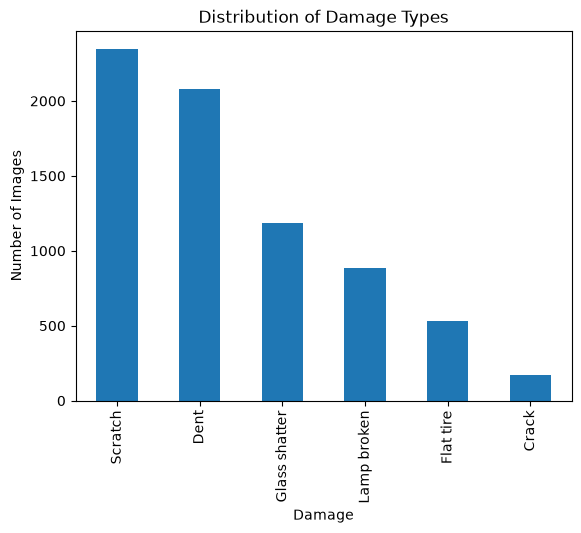

In [11]:
import matplotlib.pyplot as plt

df["damage"].value_counts().plot(kind="bar")

plt.title("Distribution of Damage Types")
plt.xlabel("Damage")
plt.ylabel("Number of Images")
plt.show()

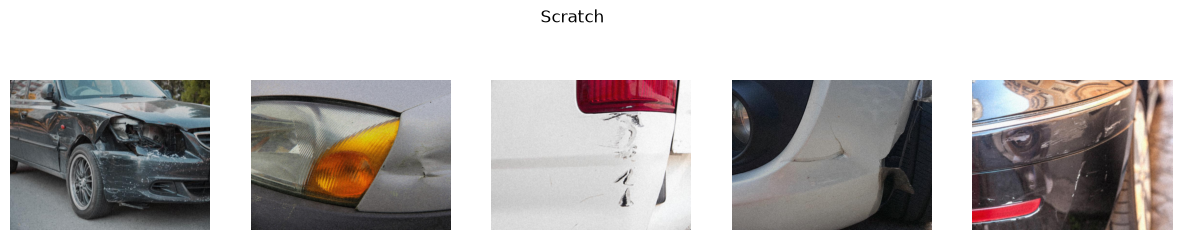

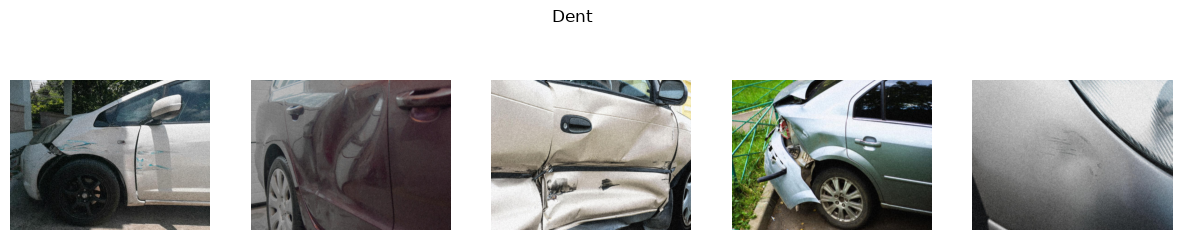

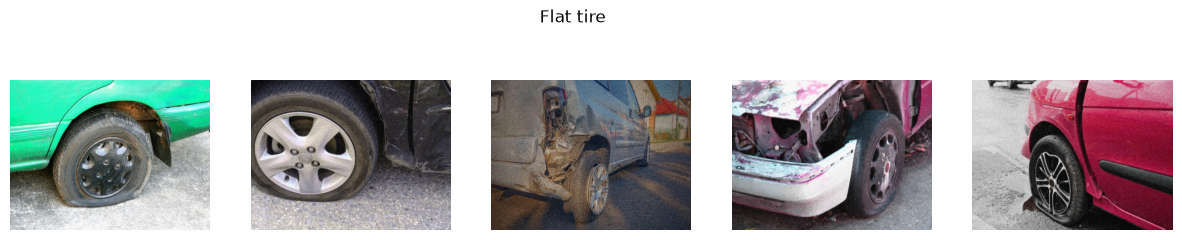

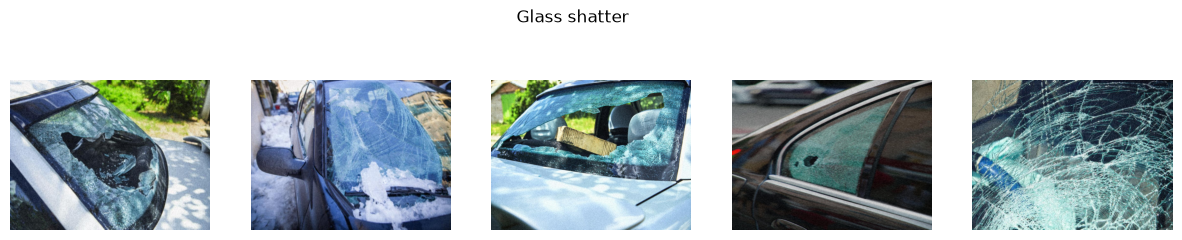

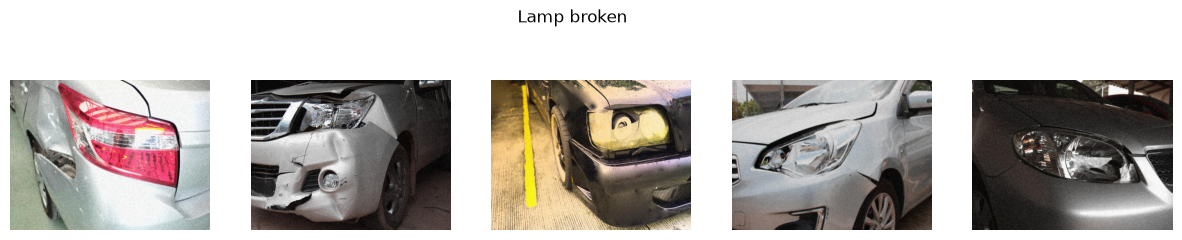

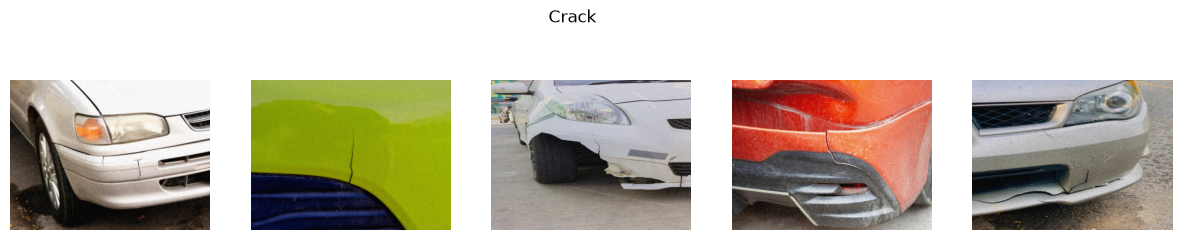

In [12]:
import matplotlib.pyplot as plt
from PIL import Image
import random

classes = df["damage"].unique()

for cls in classes:

    samples = df[df["damage"] == cls].sample(5)

    fig, axes = plt.subplots(1,5, figsize=(15,3))

    for ax, (_, row) in zip(axes, samples.iterrows()):

        img = Image.open("../data/raw/images/" + row["filename"])

        ax.imshow(img)
        ax.axis("off")

    plt.suptitle(cls)

    plt.show()

In [13]:
from PIL import Image

sizes = []

for file in df["filename"]:

    img = Image.open("../data/raw/images/" + file)

    sizes.append(img.size)

sizes[:10]

[(1440, 1080),
 (1292, 969),
 (1368, 1026),
 (1481, 1110),
 (1209, 906),
 (855, 641),
 (1375, 1031),
 (863, 647),
 (830, 622),
 (1392, 1044)]

In [14]:
from PIL import Image

bad = []

for file in df["filename"]:

    try:
        Image.open("../data/raw/images/" + file)

    except:

        bad.append(file)

print(len(bad))

0


In [17]:
print("Anzahl der Bilder:", len(df))

Anzahl der Bilder: 7200


## Image Preprocessing

-  Resize images to 224 × 224 pixels
- Normalize pixel values to [0,1]
- Split the dataset into training, validation and test sets

In [18]:
import os
import shutil
import pandas as pd

# CSV-Datei mit den Bildinformationen laden
df = pd.read_csv("../data/raw/train.csv")

# Zuordnung der numerischen Labels zu den Schadensklassen
label_map = {
    1: "Crack",
    2: "Scratch",
    3: "Flat_tire",
    4: "Dent",
    5: "Glass_shatter",
    6: "Lamp_broken"
}

# Ordner mit den Originalbildern
source_folder = "../data/raw/images"

# Zielordner für die sortierten Bilder
target_folder = "../data/damage_images"


# Ordner für jede Schadensklasse erstellen
for class_name in label_map.values():
    os.makedirs(
        os.path.join(target_folder, class_name),
        exist_ok=True
    )


# Bilder entsprechend der Schadensklasse kopieren
for _, row in df.iterrows():

    source_path = os.path.join(
        source_folder,
        row["filename"]
    )

    destination_path = os.path.join(
        target_folder,
        label_map[row["label"]],
        row["filename"]
    )

    if os.path.exists(source_path):
        shutil.copy(
            source_path,
            destination_path
        )


print("Datensatz wurde erfolgreich nach Schadensklassen organisiert.")

Datensatz wurde erfolgreich nach Schadensklassen organisiert.


In [19]:
for folder in label_map.values():
    path = os.path.join(target_folder, folder)
    print(folder, len(os.listdir(path)))

Crack 171
Scratch 2349
Flat_tire 534
Dent 2079
Glass_shatter 1185
Lamp_broken 882


In [20]:
import tensorflow as tf


data_dir = "../data/damage_images"


train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(224,224),
    batch_size=32
)


val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(224,224),
    batch_size=32
)

Found 7200 files belonging to 6 classes.
Using 5760 files for training.
Found 7200 files belonging to 6 classes.
Using 1440 files for validation.


In [21]:
import sys

print(sys.executable)

c:\Users\User\anaconda3\envs\ml_2026\python.exe


In [22]:
print(train_ds.class_names)

['Crack', 'Dent', 'Flat_tire', 'Glass_shatter', 'Lamp_broken', 'Scratch']


In [23]:
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0

In [24]:
class_names = train_ds.class_names

print(class_names)

['Crack', 'Dent', 'Flat_tire', 'Glass_shatter', 'Lamp_broken', 'Scratch']


In [25]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

In [26]:
base_model.trainable = False

In [27]:
model = models.Sequential([
    
    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.3),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(0.3),

    layers.Dense(
        6,
        activation="softmax"
    )
])

In [28]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,313 (16.08 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [29]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [30]:
print("Model ready")

Model ready


In [31]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(
    buffer_size=AUTOTUNE
)

val_ds = val_ds.prefetch(
    buffer_size=AUTOTUNE
)

In [33]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10


c:\Users\User\anaconda3\envs\ml_2026\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


180/180 ━━━━━━━━━━━━━━━━━━━━ 170s 879ms/step - accuracy: 0.6682 - loss: 0.8353 - val_accuracy: 0.7604 - val_loss: 0.5940
Epoch 2/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 154s 854ms/step - accuracy: 0.7681 - loss: 0.5847 - val_accuracy: 0.8139 - val_loss: 0.4962
Epoch 3/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 154s 857ms/step - accuracy: 0.8017 - loss: 0.5040 - val_accuracy: 0.8458 - val_loss: 0.4384
Epoch 4/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 154s 853ms/step - accuracy: 0.8290 - loss: 0.4411 - val_accuracy: 0.8528 - val_loss: 0.3974
Epoch 5/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 157s 872ms/step - accuracy: 0.8503 - loss: 0.3892 - val_accuracy: 0.8792 - val_loss: 0.3515
Epoch 6/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 153s 850ms/step - accuracy: 0.8733 - loss: 0.3456 - val_accuracy: 0.8896 - val_loss: 0.3136
Epoch 7/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 162s 900ms/step - accuracy: 0.8832 - loss: 0.3118 - val_accuracy: 0.8958 - val_loss: 0.2887
Epoch 8/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 151s 842ms/step - accuracy: 0.8953 - loss: 0.28

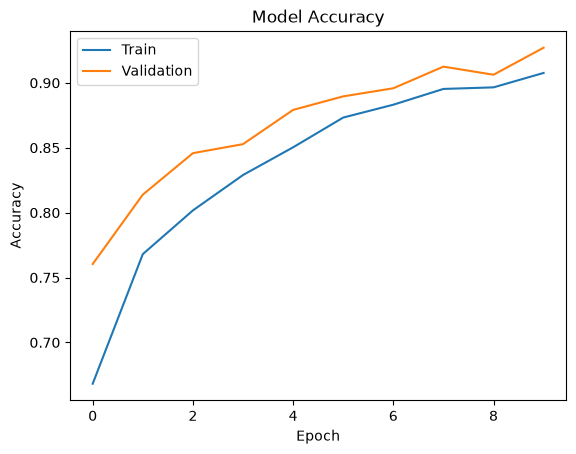

In [34]:
import matplotlib.pyplot as plt


plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])

plt.show()

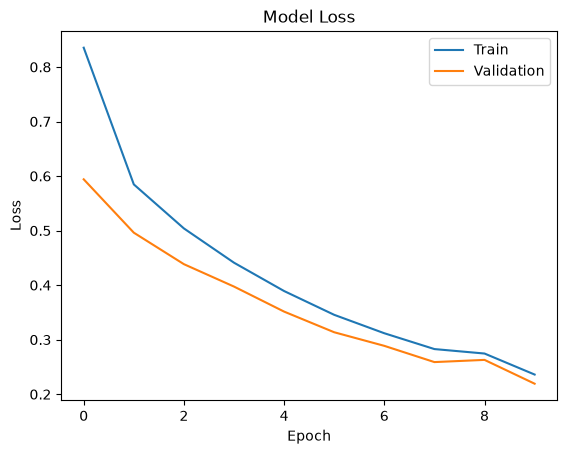

In [35]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])

plt.show()

In [36]:
import pandas as pd


history_df = pd.DataFrame(history.history)

history_df

,accuracy,loss,val_accuracy,val_loss
0,0.668229,0.835338,0.760417,0.594027
1,0.768056,0.584698,0.813889,0.496176
2,0.801736,0.503964,0.845833,0.438438
3,0.828993,0.441125,0.852778,0.397353
4,0.850347,0.389172,0.879167,0.351466
5,0.873264,0.345560,0.889583,0.313607
6,0.883160,0.311796,0.895833,0.288685
7,0.895312,0.282784,0.912500,0.258913
8,0.896528,0.274605,0.906250,0.262945
9,0.907639,0.236072,0.927083,0.219297


In [ ]:
model.evaluate(val_ds)

45/45 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.9201 - loss: 0.2222


[0.22223852574825287, 0.9201388955116272]

In [37]:
print(np.unique(y_true))
print(np.unique(y_pred))
print(class_names)

NameError: name 'y_true' is not defined

In [38]:
model.save(
    "../models/damage_cnn.keras"
)